# Asteria - Cybersecurity Data Analysis

Asteria is a cybersecurity analytics project focused on detecting
unusual system and network behavior from telemetry and log data.

In this notebook, I am starting with exploratory data analysis of
the UNSW-NB15 dataset to understand the data, identify patterns,
check data quality, and prepare the dataset for later anomaly
detection experiments.


## Objective

The main objectives of this analysis are:

- Understand the structure of the dataset
- Identify numerical and categorical features
- Check missing values and duplicate records
- Understand the distribution of normal and attack traffic
- Explore relationships between important features
- Prepare the data for machine learning experiments

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset Setup

I will start the analysis with the UNSW-NB15 dataset.

The training and testing datasets will be kept separate so that
the testing data can be used later for evaluating the models.


In [ ]:
import os

DATA_DIR = "/content/asteria_data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Data directory created:", DATA_DIR)


Data directory created: /content/asteria_data


### 2.1 Downloading the Dataset

For the initial analysis, I am using the predefined UNSW-NB15
training set. The testing set will be kept separate and used later
for model evaluation.


In [ ]:
import urllib.request

train_url = "https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_training-set.csv"
train_path = os.path.join(DATA_DIR, "UNSW_NB15_training-set.csv")

urllib.request.urlretrieve(train_url, train_path)

print("Dataset downloaded.")
print("File:", train_path)

Dataset downloaded.
File: /content/asteria_data/UNSW_NB15_training-set.csv


In [ ]:
df = pd.read_csv(train_path)

print("Dataset loaded.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded.
Rows: 175341
Columns: 45


## 3. Initial Dataset Inspection

Before performing any cleaning or visualization, I will inspect a
few records to understand how the features are represented and what
the dataset looks like at a basic level.

In [ ]:
df.head()


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 4. Dataset Structure and Data Types

In this step, I will inspect the columns, their data types, and the
number of non-null values. This helps identify which features are
numerical, categorical, or potentially require further cleaning.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

## 5. Categorical Feature Inspection

The dataset contains several categorical features. I will inspect
their unique values and frequencies before deciding how they should
be handled during preprocessing.

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


proto
Number of unique values: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
Name: count, dtype: int64

service
Number of unique values: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

state
Number of unique values: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

attack_cat
Number of unique values: 10
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


## 5. Categorical Feature Inspection

The dataset contains several categorical features. I will inspect
their unique values and frequencies before deciding how they should
be handled during preprocessing.

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


proto
Number of unique values: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
Name: count, dtype: int64

service
Number of unique values: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

state
Number of unique values: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

attack_cat
Number of unique values: 10
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:
df["label"].value_counts()

,count
label,
1,119341
0,56000


In [ ]:
df["label"].value_counts(normalize=True) * 100

,proportion
label,
1,68.062233
0,31.937767


### 6.1 Normal vs Attack Distribution

The class distribution is visualized to understand the balance between
normal and attack traffic in the training dataset.

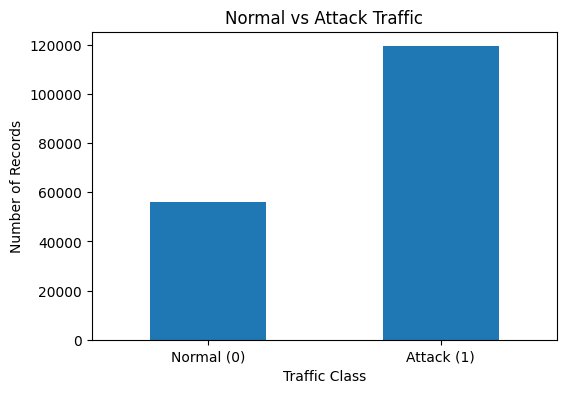

In [ ]:
plt.figure(figsize=(6, 4))

df["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.title("Normal vs Attack Traffic")
plt.xticks([0, 1], ["Normal (0)", "Attack (1)"], rotation=0)

plt.show()

## 7. Attack Category Distribution

The binary label shows whether a record is normal or an attack.
The `attack_cat` feature provides more detailed information about
the type of traffic represented in the dataset.

I will examine the distribution of these categories to identify
major and minority classes.

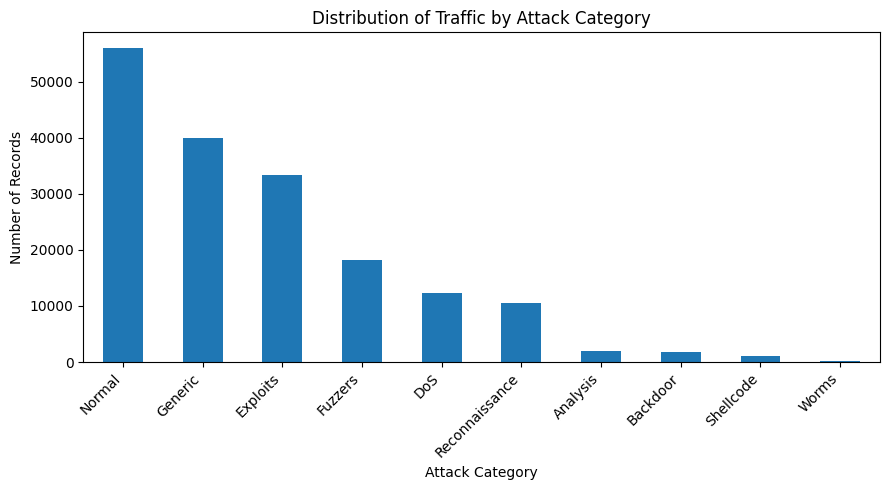

In [ ]:
attack_counts = df["attack_cat"].value_counts()

plt.figure(figsize=(9, 5))

attack_counts.sort_values(ascending=False).plot(kind="bar")

plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.title("Distribution of Traffic by Attack Category")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
attack_only = df[df["label"] == 1]["attack_cat"]

print("Number of attack records:", len(attack_only))
print("Number of attack categories:", attack_only.nunique())
print("\nAttack category counts:")
print(attack_only.value_counts())

Number of attack records: 119341
Number of attack categories: 9

Attack category counts:
attack_cat
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


## 8. Missing Value Analysis

I will check each feature for missing values. This is important before
further analysis because missing values can affect statistical
calculations and machine learning models.

In [ ]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


## 9. Duplicate Record Analysis

Duplicate records can affect statistical analysis and may cause
certain observations to be overrepresented. I will check whether
the dataset contains exact duplicate rows.

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 10. Numerical Feature Statistics

I will examine descriptive statistics for the numerical features to
understand their ranges, central tendencies, and variability.

This includes measures such as the mean, standard deviation, minimum,
maximum, and quartiles. These statistics will help identify features
with large variations or potentially unusual values.

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,175341.0,8.767100e+04,5.061673e+04,1.0,43836.000000,87671.000000,1.315060e+05,1.753410e+05
dur,175341.0,1.359389e+00,6.480249e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540619e+04,1.654010e+05,0.0,32.786140,3225.806520,1.250000e+05,1.000000e+06
sttl,175341.0,1.795470e+02,1.029400e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,175341.0,7.960957e+01,1.105069e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.338870,879674.750000,8.888889e+07,5.988000e+09


## 11. Numerical Feature Distributions

Summary statistics provide numerical information about the features,
but visualizations help reveal the shape of their distributions.

I will inspect selected numerical features to identify skewness,
concentration of values, and potentially extreme observations.

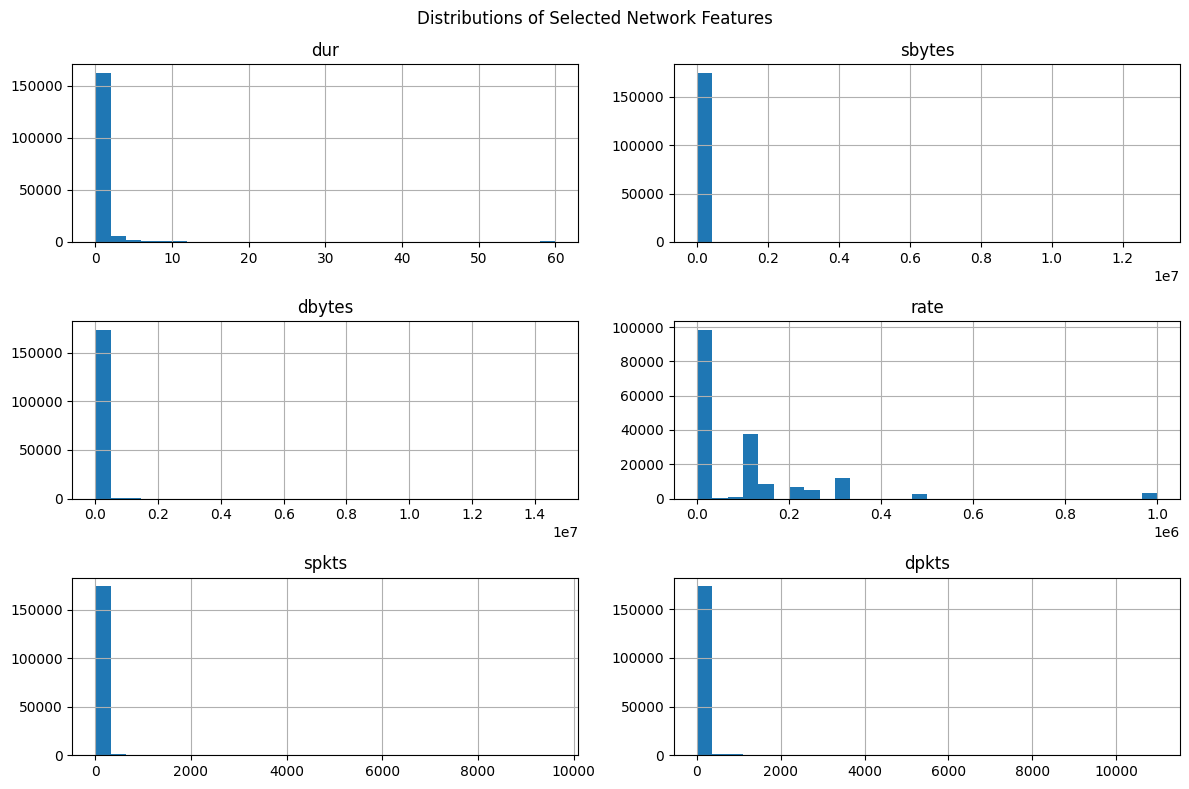

In [ ]:
selected_features = [
    "dur",
    "sbytes",
    "dbytes",
    "rate",
    "spkts",
    "dpkts"
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Distributions of Selected Network Features")
plt.tight_layout()
plt.show()

## 12. Normal vs Attack Feature Comparison

The previous analysis examined the overall distribution of selected
network features. In this step, I will compare these features between
normal and attack traffic to identify whether their distributions
differ across the two classes.

These differences can help identify features that may be useful for
later anomaly detection and classification experiments.

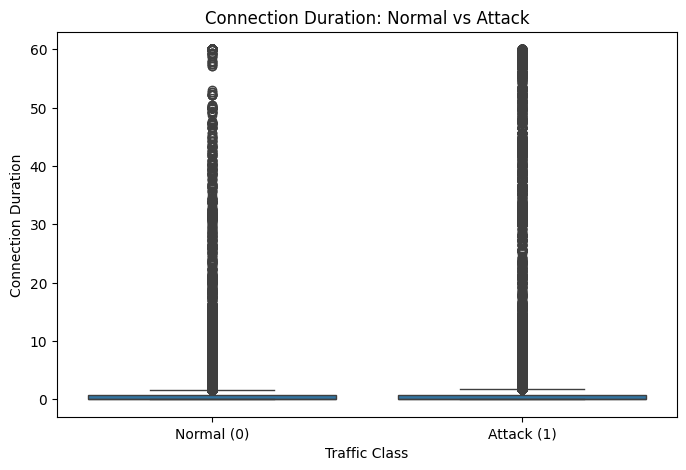

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="dur"
)

plt.xlabel("Traffic Class")
plt.ylabel("Connection Duration")
plt.title("Connection Duration: Normal vs Attack")
plt.xticks([0, 1], ["Normal (0)", "Attack (1)"])

plt.show()

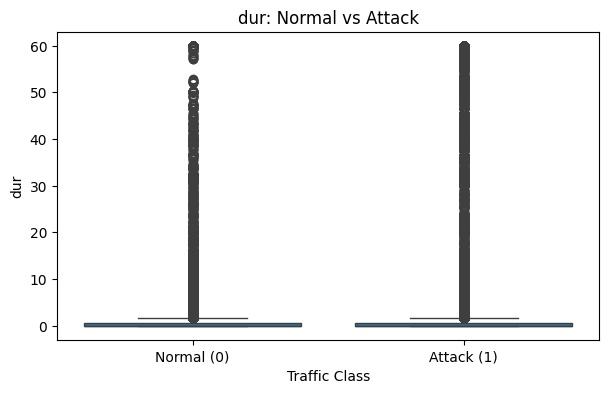

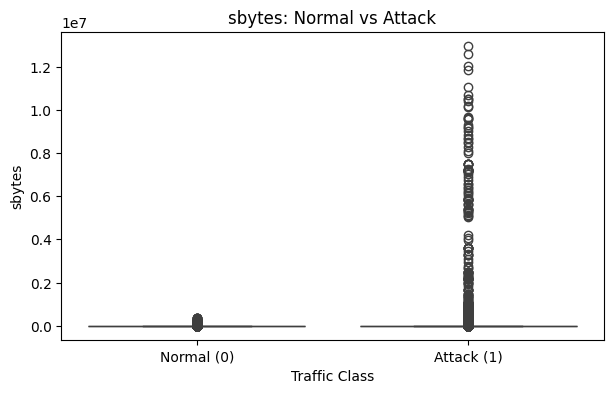

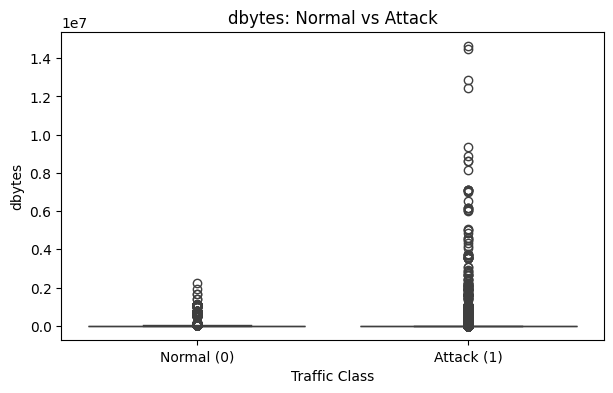

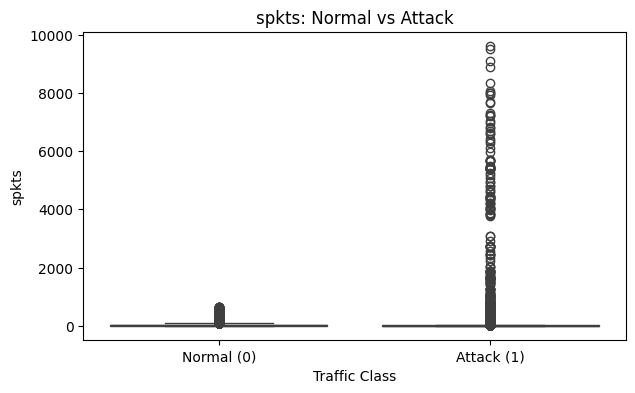

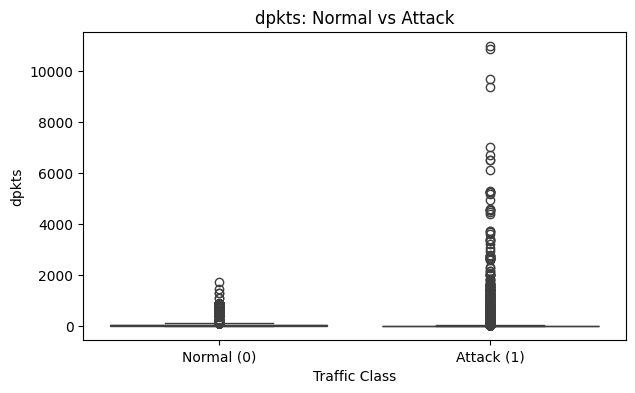

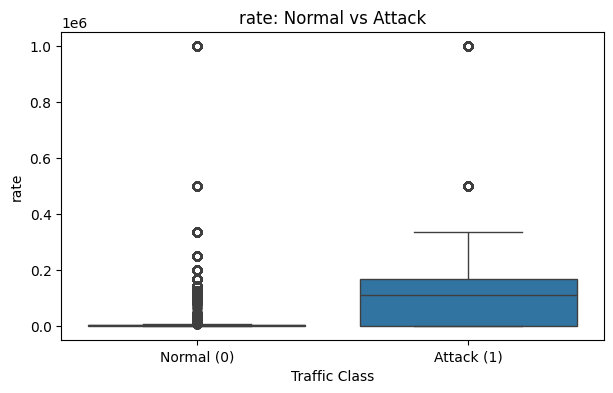

In [ ]:
comparison_features = [
    "dur",
    "sbytes",
    "dbytes",
    "spkts",
    "dpkts",
    "rate"
]

for feature in comparison_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="label",
        y=feature
    )

    plt.xlabel("Traffic Class")
    plt.ylabel(feature)
    plt.title(f"{feature}: Normal vs Attack")
    plt.xticks([0, 1], ["Normal (0)", "Attack (1)"])

    plt.show()

## 13. Correlation Analysis

Correlation analysis is used to examine the relationship between
numerical features.

This helps identify features that move together and may contain
similar information. It can also help understand relationships
between network traffic characteristics before building machine
learning models.

In [ ]:
numeric_features = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_features.corr()

correlation_matrix.round(2)

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
id,1.00,0.01,-0.07,-0.13,0.00,-0.08,0.36,0.62,-0.05,0.14,...,0.54,0.60,0.54,-0.04,-0.04,-0.03,0.43,0.48,0.03,0.73
dur,0.01,1.00,0.25,0.18,0.20,0.14,-0.12,0.01,0.04,-0.08,...,-0.09,-0.09,-0.10,0.02,0.02,0.02,-0.08,-0.12,0.04,0.04
spkts,-0.07,0.25,1.00,0.39,0.96,0.21,-0.08,-0.10,0.07,-0.05,...,-0.07,-0.07,-0.08,0.01,0.01,0.01,-0.06,-0.07,-0.02,-0.05
dpkts,-0.13,0.18,0.39,1.00,0.19,0.97,-0.10,-0.19,0.05,-0.07,...,-0.09,-0.09,-0.09,0.01,0.01,0.05,-0.08,-0.08,-0.02,-0.12
sbytes,0.00,0.20,0.96,0.19,1.00,0.01,-0.03,-0.02,0.06,-0.02,...,-0.03,-0.03,-0.03,-0.00,-0.00,-0.00,-0.03,-0.03,-0.01,0.02
dbytes,-0.08,0.14,0.21,0.97,0.01,1.00,-0.06,-0.14,0.02,-0.04,...,-0.05,-0.06,-0.05,-0.01,-0.01,0.05,-0.05,-0.04,-0.01,-0.08
rate,0.36,-0.12,-0.08,-0.10,-0.03,-0.06,1.00,0.41,-0.41,0.60,...,0.35,0.39,0.38,-0.07,-0.07,-0.11,0.31,0.36,-0.07,0.34
sttl,0.62,0.01,-0.10,-0.19,-0.02,-0.14,0.41,1.00,-0.03,0.28,...,0.34,0.38,0.40,-0.12,-0.12,-0.11,0.27,0.34,-0.22,0.69
dttl,-0.05,0.04,0.07,0.05,0.06,0.02,-0.41,-0.03,1.00,-0.28,...,-0.37,-0.39,-0.40,0.11,0.11,0.22,-0.37,-0.43,-0.09,0.10
sload,0.14,-0.08,-0.05,-0.07,-0.02,-0.04,0.60,0.28,-0.28,1.00,...,0.10,0.08,0.16,-0.05,-0.05,-0.07,0.08,0.14,-0.05,0.18


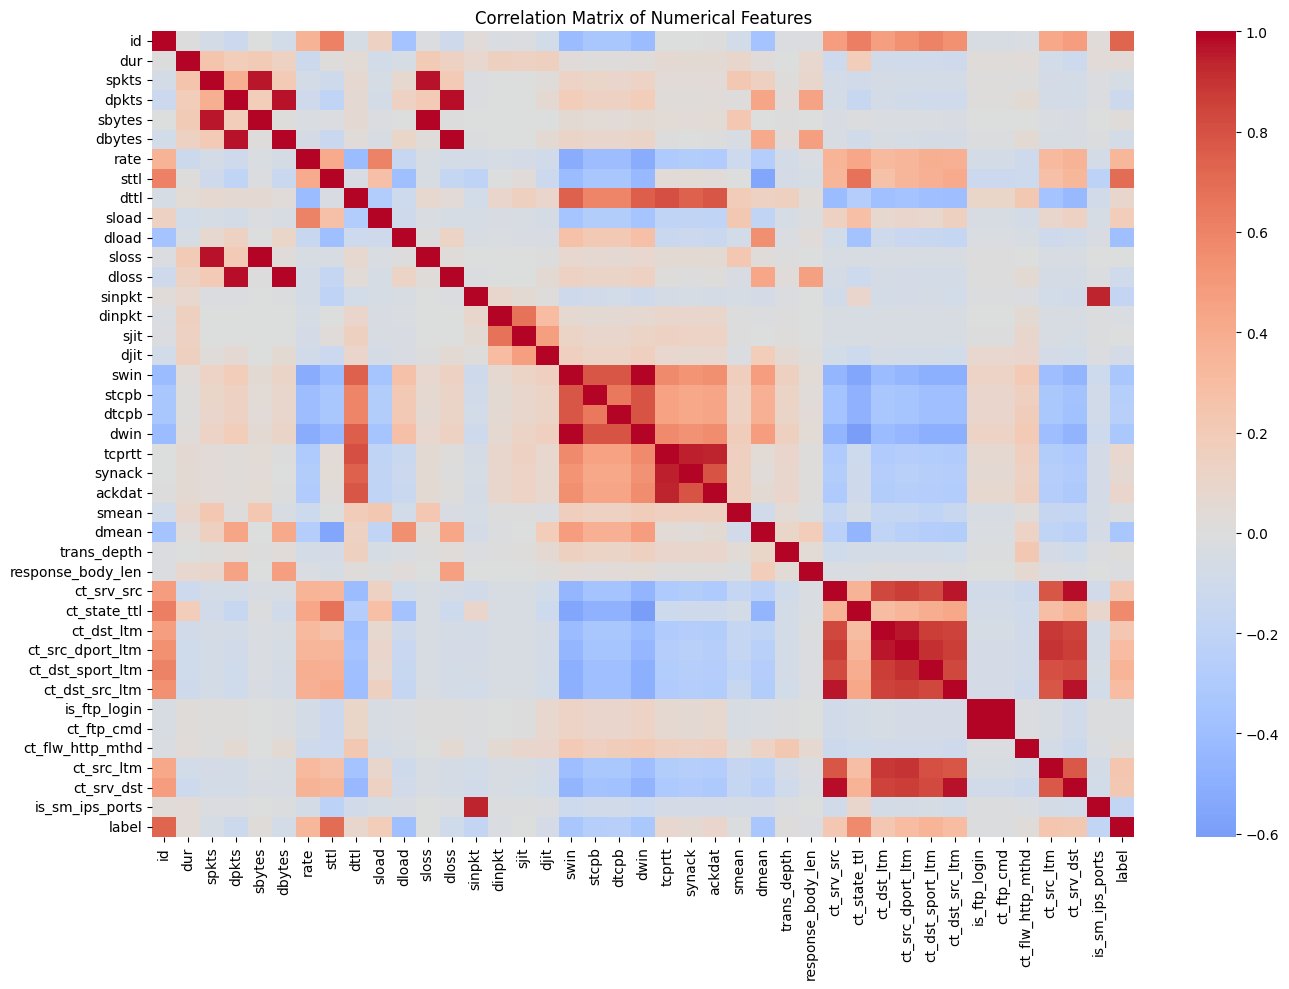

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
feature_columns = [
    col for col in numeric_features.columns
    if col not in ["id", "label"]
]

feature_correlation = df[feature_columns].corr()

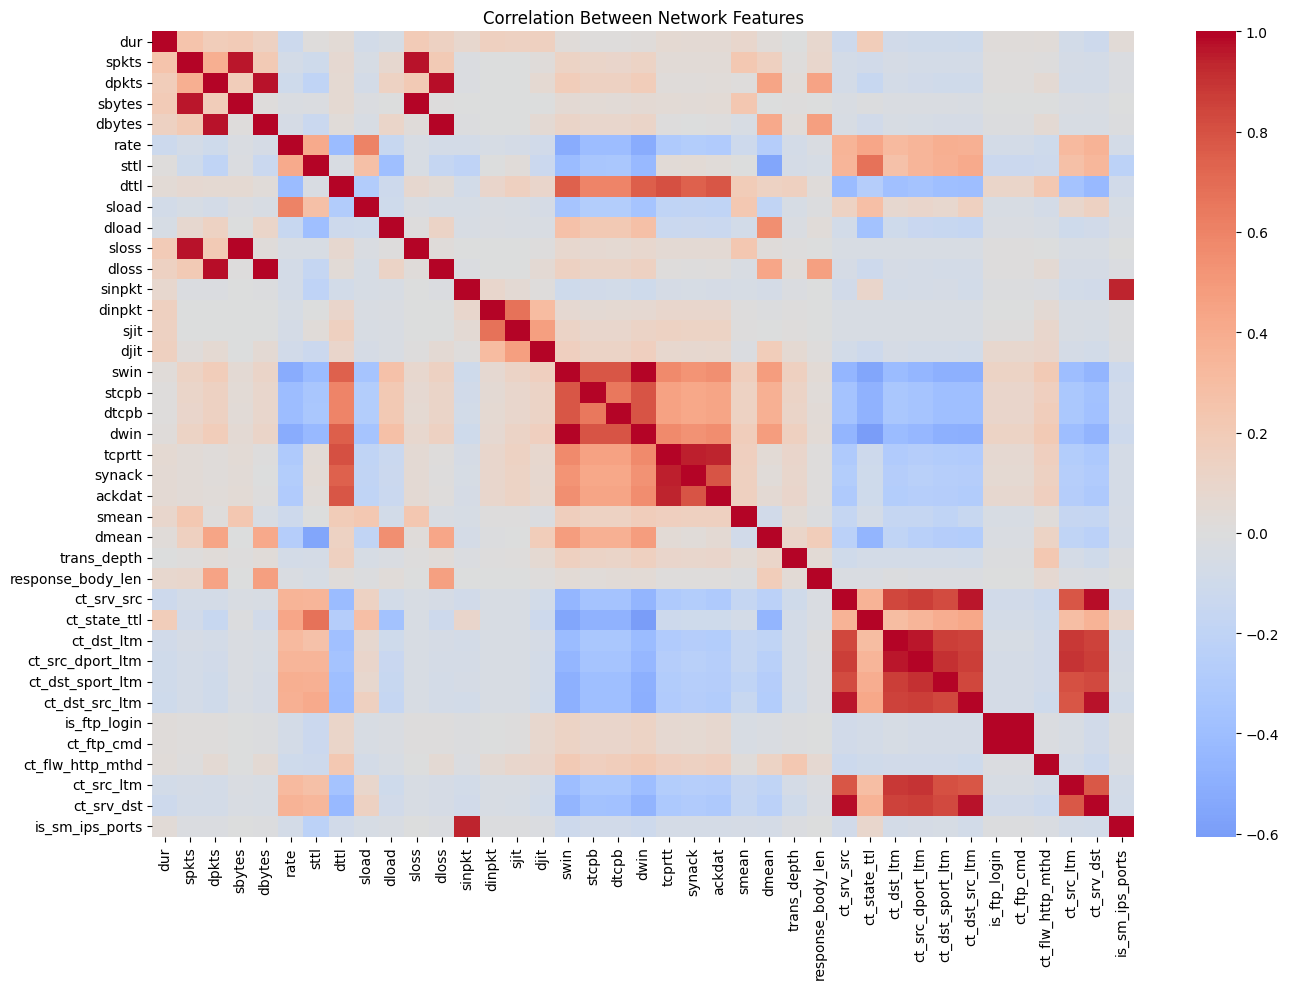

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    feature_correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Network Features")
plt.tight_layout()
plt.show()

## 14. Feature-Level Analysis

Correlation shows relationships between features, but it does not tell us
directly how each feature behaves for normal and attack traffic.

In this step, I will compare the distributions of selected numerical
features across the two classes.

This helps identify features that may contain useful behavioral information
for later anomaly detection and machine learning experiments.

In [ ]:
feature_summary = df.groupby("label")[[
    "dur",
    "sbytes",
    "dbytes",
    "spkts",
    "dpkts",
    "rate"
]].mean()

feature_summary

,dur,sbytes,dbytes,spkts,dpkts,rate
label,,,,,,
0,1.017177,4105.702929,31049.463143,30.725482,38.057696,13799.312118
1,1.519969,11068.655357,7364.456256,15.405946,10.012619,133699.690589


In [ ]:
feature_median = df.groupby("label")[[
    "dur",
    "sbytes",
    "dbytes",
    "spkts",
    "dpkts",
    "rate"
]].median()

feature_median

,dur,sbytes,dbytes,spkts,dpkts,rate
label,,,,,,
0,0.038602,1470.0,1112.0,12.0,10.0,1382.256617
1,0.000009,200.0,0.0,2.0,0.0,111111.107200


## 15. Feature Skewness Analysis

Some network features can have highly skewed distributions because a small
number of connections may generate unusually large traffic volumes.

I will calculate the skewness of numerical features to identify features
with strongly asymmetric distributions.

This will help determine whether transformations or scaling may be useful
during later preprocessing.

In [ ]:
skewness = numeric_df.drop(columns=["id", "label"]).skew()

skewness.sort_values(ascending=False)

,0
trans_depth,167.335829
response_body_len,76.340075
sbytes,45.303443
sloss,44.753662
dloss,41.380270
spkts,40.217703
dbytes,39.760864
dpkts,36.764114
dinpkt,29.679512
djit,29.543830


In [ ]:
highly_skewed = skewness[abs(skewness) > 2].sort_values(ascending=False)

highly_skewed

,0
trans_depth,167.335829
response_body_len,76.340075
sbytes,45.303443
sloss,44.753662
dloss,41.380270
spkts,40.217703
dbytes,39.760864
dpkts,36.764114
dinpkt,29.679512
djit,29.543830


## 16. Outlier Analysis

Outliers are observations that are unusually far from the typical range
of a feature.

In cybersecurity data, extreme values should not automatically be removed,
because unusual traffic may represent meaningful malicious behavior.

I will use the IQR method to identify potential outliers in selected
network features.

In [ ]:
outlier_features = [
    "dur",
    "sbytes",
    "dbytes",
    "spkts",
    "dpkts",
    "rate"
]

outlier_summary = []

for feature in outlier_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": (len(outliers) / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,dur,0.000008,0.668069,0.668061,-1.002084,1.670161,15741,8.977364
1,sbytes,114.000000,1418.000000,1304.000000,-1842.000000,3374.000000,22873,13.044867
2,dbytes,0.000000,1102.000000,1102.000000,-1653.000000,2755.000000,28131,16.043595
3,spkts,2.000000,12.000000,10.000000,-13.000000,27.000000,24675,14.072579
4,dpkts,0.000000,10.000000,10.000000,-15.000000,25.000000,20830,11.879709
5,rate,32.786140,125000.000300,124967.214160,-187418.035100,312450.821540,17340,9.889301


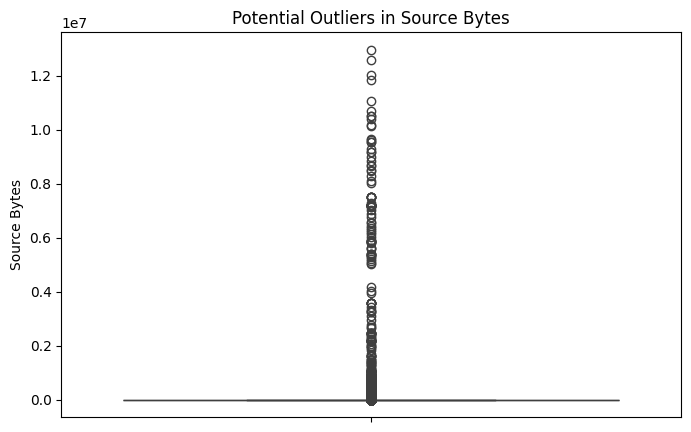

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="sbytes"
)

plt.title("Potential Outliers in Source Bytes")
plt.ylabel("Source Bytes")

plt.show()

## 17. Normal vs Attack Distribution Comparison

The previous analysis compared summary statistics between normal and attack
traffic.

In this step, I will visualize the distributions of selected network
features separately for the two classes.

This helps identify whether attack traffic exhibits different behavioral
patterns from normal traffic.

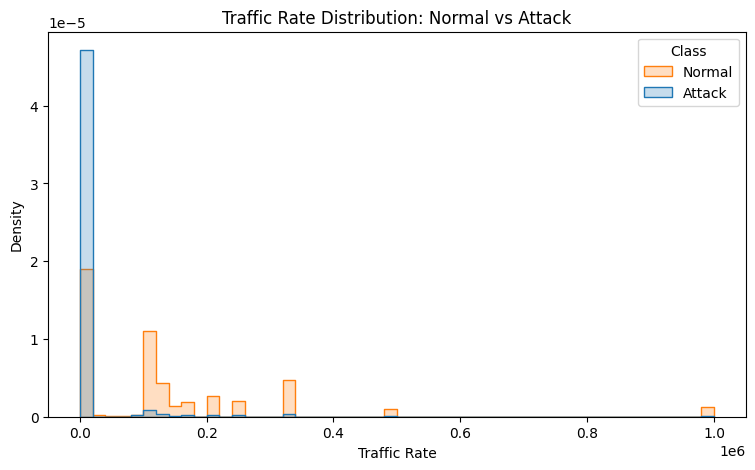

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="rate",
    hue="label",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.xlabel("Traffic Rate")
plt.ylabel("Density")
plt.title("Traffic Rate Distribution: Normal vs Attack")
plt.legend(title="Class", labels=["Normal", "Attack"])

plt.show()

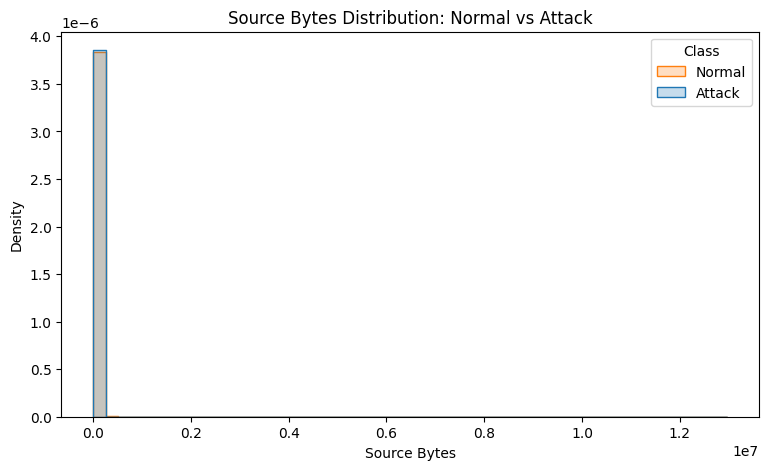

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="sbytes",
    hue="label",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.xlabel("Source Bytes")
plt.ylabel("Density")
plt.title("Source Bytes Distribution: Normal vs Attack")
plt.legend(title="Class", labels=["Normal", "Attack"])

plt.show()

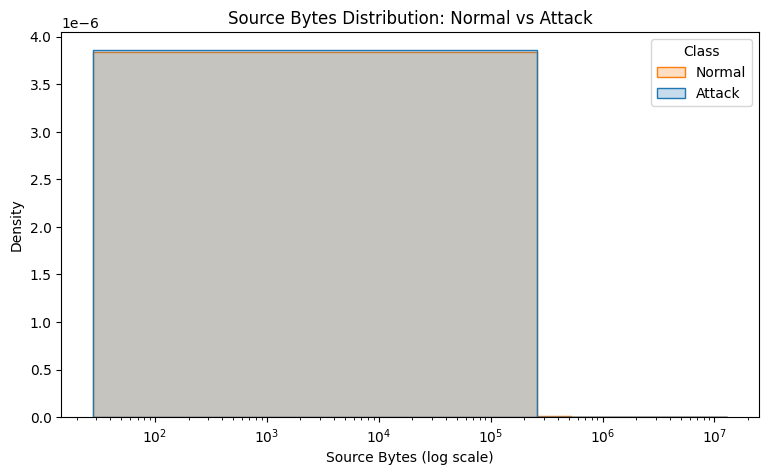

In [ ]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="sbytes",
    hue="label",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.xscale("log")

plt.xlabel("Source Bytes (log scale)")
plt.ylabel("Density")
plt.title("Source Bytes Distribution: Normal vs Attack")
plt.legend(title="Class", labels=["Normal", "Attack"])

plt.show()

## 18. Categorical Features vs Attack Behavior

Categorical features describe properties such as the communication protocol,
network service, and connection state.

In this step, I will compare the distribution of these categorical features
between normal and attack traffic.

This helps identify whether certain categorical behaviors are more common
within particular traffic classes.

In [ ]:
protocol_distribution = pd.crosstab(
    df["proto"],
    df["label"]
)

protocol_distribution.columns = ["Normal", "Attack"]

protocol_distribution.sort_values(
    "Attack",
    ascending=False
).head(15)

,Normal,Attack
proto,,
udp,13922,49361
tcp,39121,40825
unas,0,12084
ospf,64,2531
sctp,0,1150
any,0,300
gre,0,225
swipe,0,201
ipv6,0,201


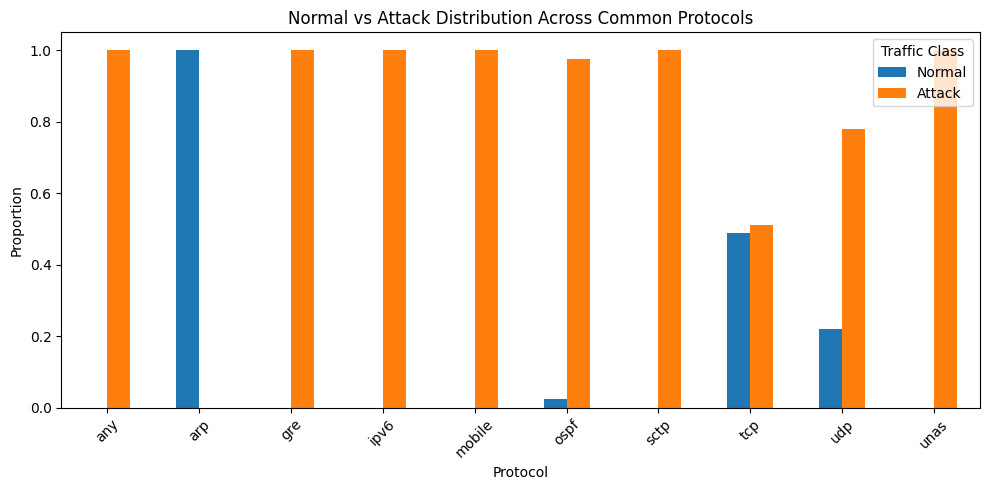

In [ ]:
top_protocols = df["proto"].value_counts().head(10).index

protocol_plot = pd.crosstab(
    df[df["proto"].isin(top_protocols)]["proto"],
    df[df["proto"].isin(top_protocols)]["label"],
    normalize="index"
)

protocol_plot.columns = ["Normal", "Attack"]

protocol_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Protocol")
plt.ylabel("Proportion")
plt.title("Normal vs Attack Distribution Across Common Protocols")
plt.xticks(rotation=45)
plt.legend(title="Traffic Class")

plt.tight_layout()
plt.show()

In [ ]:
service_distribution = pd.crosstab(
    df["service"],
    df["label"]
)

service_distribution.columns = ["Normal", "Attack"]

service_distribution.sort_values(
    "Attack",
    ascending=False
)

,Normal,Attack
service,,
-,36512,57656
dns,7493,39801
http,5348,13376
smtp,1579,3479
ftp,1218,2210
ftp-data,2552,1443
pop3,4,1101
dhcp,0,94
snmp,1,79


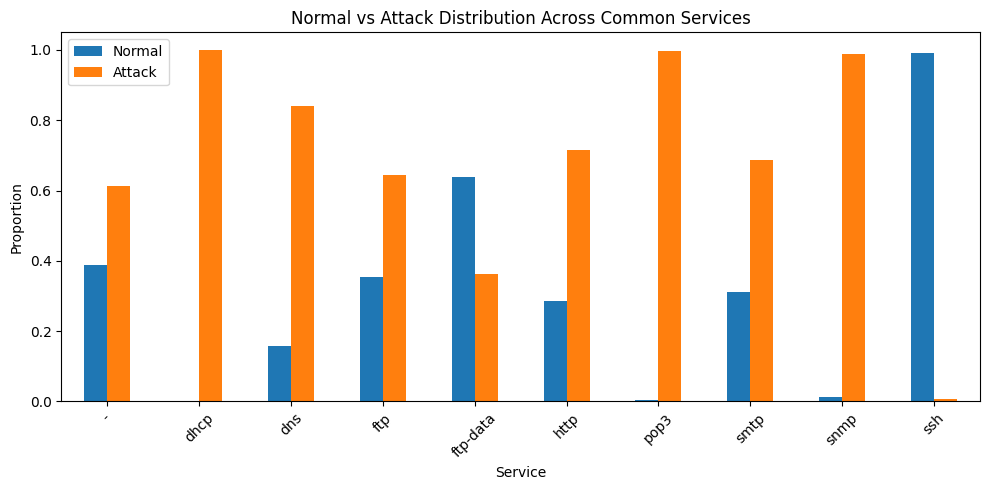

In [ ]:
top_services = df["service"].value_counts().head(10).index

service_plot = pd.crosstab(
    df[df["service"].isin(top_services)]["service"],
    df[df["service"].isin(top_services)]["label"],
    normalize="index"
)

service_plot.columns = ["Normal", "Attack"]

service_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Service")
plt.ylabel("Proportion")
plt.title("Normal vs Attack Distribution Across Common Services")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
state_distribution = pd.crosstab(
    df["state"],
    df["label"]
)

state_distribution.columns = ["Normal", "Attack"]

state_distribution

,Normal,Attack
state,,
CON,12099,1053
ECO,12,0
FIN,37175,40650
INT,5715,76560
PAR,1,0
REQ,925,1066
RST,71,12
URN,1,0
no,1,0


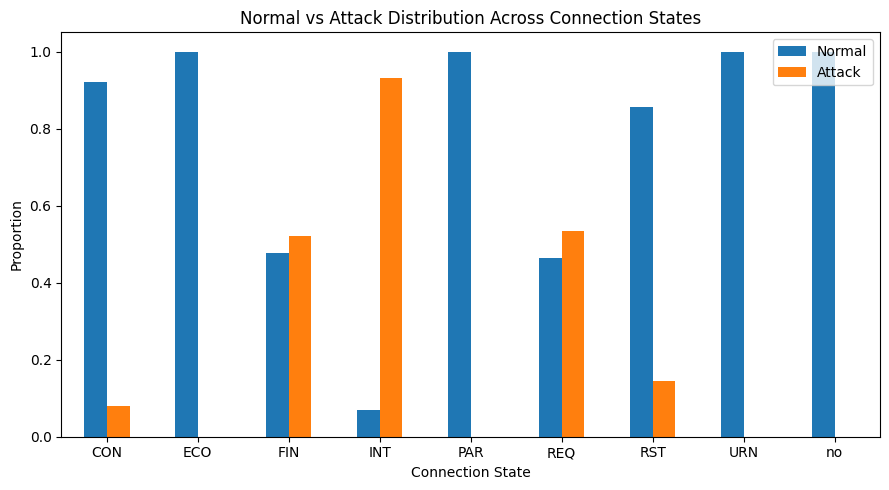

In [ ]:
state_plot = pd.crosstab(
    df["state"],
    df["label"],
    normalize="index"
)

state_plot.columns = ["Normal", "Attack"]

state_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Connection State")
plt.ylabel("Proportion")
plt.title("Normal vs Attack Distribution Across Connection States")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 19. Attack Category Behavioral Analysis

The binary label separates normal traffic from attack traffic, while
`attack_cat` provides a more detailed classification of malicious activity.

In this step, I will compare selected network features across different
attack categories to understand whether different attack types exhibit
different behavioral characteristics.

In [ ]:
attack_df = df[df["attack_cat"] != "Normal"].copy()

print("Attack records:", len(attack_df))
print("Attack categories:", attack_df["attack_cat"].nunique())

Attack records: 119341
Attack categories: 9


In [ ]:
attack_behavior = attack_df.groupby("attack_cat")[[
    "dur",
    "sbytes",
    "dbytes",
    "spkts",
    "dpkts",
    "rate"
]].mean()

attack_behavior

,dur,sbytes,dbytes,spkts,dpkts,rate
attack_cat,,,,,,
Analysis,1.801745,1029.638000,361.151000,6.112500,2.594000,140031.118686
Backdoor,2.658846,1834.583047,341.096220,7.563001,1.666667,147399.796935
DoS,2.574937,17272.011416,18969.224478,22.524625,18.689008,151574.783077
Exploits,2.258554,28344.317971,16702.776540,32.717516,22.161830,73646.759658
Fuzzers,2.858527,7286.696326,520.602233,14.422019,6.196656,67191.441498
Generic,0.061187,396.043200,1078.600375,2.472825,0.935050,216796.961636
Reconnaissance,1.060093,772.140120,2291.049185,7.057097,5.276523,103843.882902
Shellcode,0.366961,529.744042,145.339806,5.932921,3.265666,100977.775414
Worms,1.428988,2403.438462,79681.684615,18.707692,64.830769,20857.493466


In [ ]:
attack_behavior_median = attack_df.groupby("attack_cat")[[
    "dur",
    "sbytes",
    "dbytes",
    "spkts",
    "dpkts",
    "rate"
]].median()

attack_behavior_median

,dur,sbytes,dbytes,spkts,dpkts,rate
attack_cat,,,,,,
Analysis,0.000009,200.0,0.0,2.0,0.0,111111.107200
Backdoor,0.000009,200.0,0.0,2.0,0.0,111111.107200
DoS,0.000009,200.0,0.0,2.0,0.0,111111.107200
Exploits,0.486540,828.0,354.0,10.0,8.0,57.541243
Fuzzers,0.617445,914.0,268.0,10.0,6.0,32.341335
Generic,0.000008,114.0,0.0,2.0,0.0,125000.000300
Reconnaissance,0.187315,564.0,0.0,10.0,0.0,78.970644
Shellcode,0.000021,536.0,0.0,2.0,0.0,47619.048000
Worms,0.548669,1302.0,268.0,10.0,6.0,42.922151


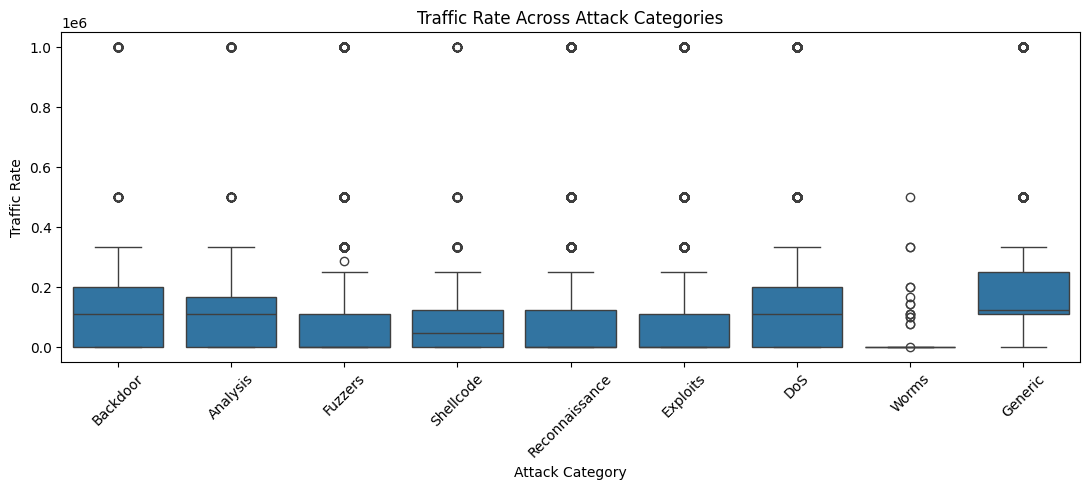

In [ ]:
plt.figure(figsize=(11, 5))

sns.boxplot(
    data=attack_df,
    x="attack_cat",
    y="rate"
)

plt.xlabel("Attack Category")
plt.ylabel("Traffic Rate")
plt.title("Traffic Rate Across Attack Categories")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

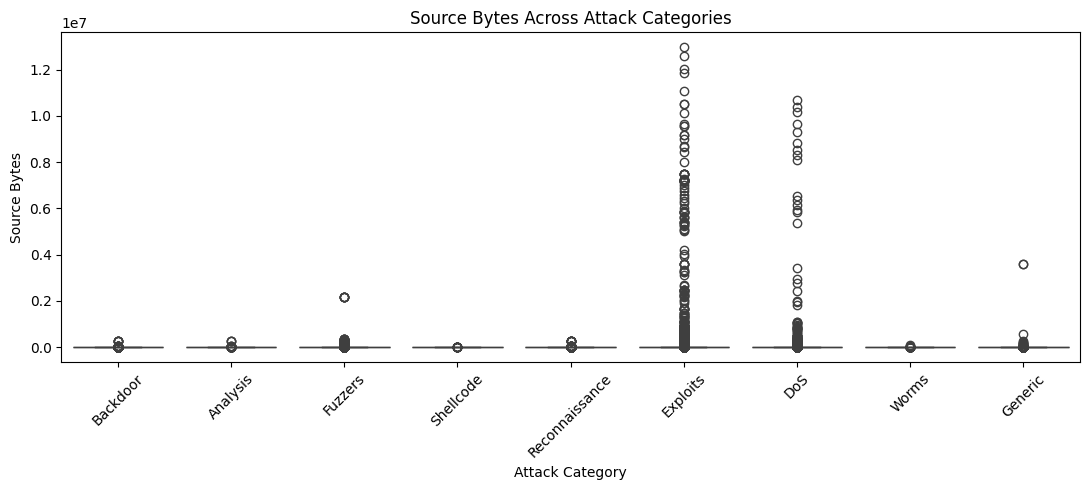

In [ ]:
plt.figure(figsize=(11, 5))

sns.boxplot(
    data=attack_df,
    x="attack_cat",
    y="sbytes"
)

plt.xlabel("Attack Category")
plt.ylabel("Source Bytes")
plt.title("Source Bytes Across Attack Categories")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 20. Feature Usefulness Analysis

Not all columns in the dataset should be treated as machine learning
features.

Some columns identify records, while others contain target information.
The remaining features describe characteristics of the network activity.

In this step, I will separate these types of columns and examine the
relationship between the numerical features and the target label.

In [ ]:
target_columns = ["label", "attack_cat"]
identifier_columns = ["id"]

excluded_columns = target_columns + identifier_columns

model_candidate_features = [
    col for col in df.columns
    if col not in excluded_columns
]

print("Number of candidate features:", len(model_candidate_features))
print("\nCandidate features:")
print(model_candidate_features)

Number of candidate features: 42

Candidate features:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [ ]:
candidate_numeric = df[
    [col for col in model_candidate_features
     if df[col].dtype != "object"]
]

print("Numerical candidate features:", candidate_numeric.shape[1])
print(candidate_numeric.columns.tolist())

Numerical candidate features: 39
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


## 21. Quantitative Feature Comparison

Visualizations provide an intuitive view of feature differences, but a
numerical comparison can help identify which features differ most between
normal and attack traffic.

I will compare the median of each numerical feature between the normal and
attack classes.

The median is used because several network features are strongly skewed
and may contain extreme observations.

In [ ]:
normal_median = df[df["label"] == 0][candidate_numeric.columns].median()
attack_median = df[df["label"] == 1][candidate_numeric.columns].median()

feature_comparison = pd.DataFrame({
    "Normal Median": normal_median,
    "Attack Median": attack_median
})

feature_comparison["Absolute Difference"] = (
    feature_comparison["Attack Median"] -
    feature_comparison["Normal Median"]
).abs()

feature_comparison.sort_values(
    "Absolute Difference",
    ascending=False
).head(15)

,Normal Median,Attack Median,Absolute Difference
stcpb,1.180207e+09,0.000000e+00,1.180207e+09
dtcpb,1.152046e+09,0.000000e+00,1.152046e+09
sload,4.313277e+05,5.066666e+07,5.023534e+07
dload,3.361206e+05,0.000000e+00,3.361206e+05
rate,1.382257e+03,1.111111e+05,1.097289e+05
sbytes,1.470000e+03,2.000000e+02,1.270000e+03
dbytes,1.112000e+03,0.000000e+00,1.112000e+03
dwin,2.550000e+02,0.000000e+00,2.550000e+02
swin,2.550000e+02,0.000000e+00,2.550000e+02
sttl,3.100000e+01,2.540000e+02,2.230000e+02


In [ ]:
normal_mean = df[df["label"] == 0][candidate_numeric.columns].mean()
attack_mean = df[df["label"] == 1][candidate_numeric.columns].mean()

normal_std = df[df["label"] == 0][candidate_numeric.columns].std()
attack_std = df[df["label"] == 1][candidate_numeric.columns].std()

pooled_std = np.sqrt(
    (normal_std ** 2 + attack_std ** 2) / 2
)

effect_size = (
    (attack_mean - normal_mean) / pooled_std
).abs()

feature_effect = pd.DataFrame({
    "Normal Mean": normal_mean,
    "Attack Mean": attack_mean,
    "Effect Size": effect_size
})

feature_effect.sort_values(
    "Effect Size",
    ascending=False
).head(15)

,Normal Mean,Attack Mean,Effect Size
sttl,7.544598e+01,2.283957e+02,1.943041
ct_state_ttl,4.992857e-01,1.681870e+00,1.397283
ct_dst_sport_ltm,1.190304e+00,5.621471e+00,0.933985
rate,1.379931e+04,1.336997e+05,0.869163
ct_src_dport_ltm,1.793804e+00,7.067998e+00,0.785284
swin,1.781126e+02,8.723218e+01,0.763625
ct_dst_src_ltm,3.870000e+00,1.101035e+01,0.762226
dload,2.062949e+06,1.813877e+04,0.734571
dwin,1.742184e+02,8.723218e+01,0.726045
dmean,2.530674e+02,6.369069e+01,0.709962


## 22. Feature-to-Behavior Analysis

Statistical differences between normal and attack traffic are useful,
but the features should also be interpreted from a cybersecurity
perspective.

In this step, I will group selected network features according to the
type of behavior they represent and examine their potential relevance
to anomaly detection.

In [ ]:
feature_meaning = {
    "dur": "Connection duration",
    "spkts": "Packets sent by source",
    "dpkts": "Packets received by destination",
    "sbytes": "Bytes sent by source",
    "dbytes": "Bytes received by destination",
    "rate": "Traffic rate",
    "sttl": "Source time-to-live",
    "dttl": "Destination time-to-live",
    "sload": "Source bits per second",
    "dload": "Destination bits per second",
    "sloss": "Source packet loss",
    "dloss": "Destination packet loss",
    "sinpkt": "Source inter-packet arrival time",
    "dinpkt": "Destination inter-packet arrival time",
    "sjit": "Source jitter",
    "djit": "Destination jitter"
}

feature_meaning_df = pd.DataFrame(
    list(feature_meaning.items()),
    columns=["Feature", "Behavior"]
)

feature_meaning_df

,Feature,Behavior
0,dur,Connection duration
1,spkts,Packets sent by source
2,dpkts,Packets received by destination
3,sbytes,Bytes sent by source
4,dbytes,Bytes received by destination
5,rate,Traffic rate
6,sttl,Source time-to-live
7,dttl,Destination time-to-live
8,sload,Source bits per second
9,dload,Destination bits per second


In [ ]:
feature_analysis = feature_effect.reset_index()

feature_analysis = feature_analysis.rename(
    columns={"index": "Feature"}
)

feature_analysis = feature_analysis.merge(
    feature_meaning_df,
    on="Feature",
    how="left"
)

feature_analysis.sort_values(
    "Effect Size",
    ascending=False
).head(15)

,Feature,Normal Mean,Attack Mean,Effect Size,Behavior
6,sttl,7.544598e+01,2.283957e+02,1.943041,Source time-to-live
28,ct_state_ttl,4.992857e-01,1.681870e+00,1.397283,NaN
31,ct_dst_sport_ltm,1.190304e+00,5.621471e+00,0.933985,NaN
5,rate,1.379931e+04,1.336997e+05,0.869163,Traffic rate
30,ct_src_dport_ltm,1.793804e+00,7.067998e+00,0.785284,NaN
16,swin,1.781126e+02,8.723218e+01,0.763625,NaN
32,ct_dst_src_ltm,3.870000e+00,1.101035e+01,0.762226,NaN
9,dload,2.062949e+06,1.813877e+04,0.734571,Destination bits per second
19,dwin,1.742184e+02,8.723218e+01,0.726045,NaN
24,dmean,2.530674e+02,6.369069e+01,0.709962,NaN


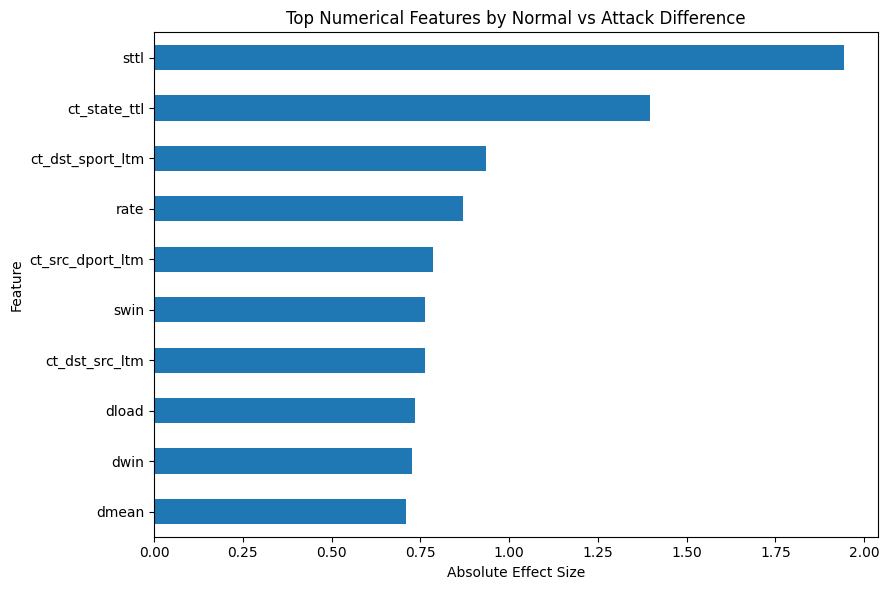

In [ ]:
top_features = (
    feature_effect["Effect Size"]
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

top_features.plot(kind="barh")

plt.xlabel("Absolute Effect Size")
plt.ylabel("Feature")
plt.title("Top Numerical Features by Normal vs Attack Difference")

plt.tight_layout()
plt.show()

## 23. Feature Redundancy Analysis

Highly correlated features may contain overlapping information.

In this step, I will identify pairs of numerical features with strong
correlations. This helps understand redundancy in the feature space and
will inform later feature-selection and preprocessing decisions.

Correlation alone will not be used to automatically remove features,
because correlated features can still provide useful information to
some machine learning models.

In [ ]:
corr_matrix = candidate_numeric.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Absolute Correlation"
]

high_correlations = high_correlations.sort_values(
    "Absolute Correlation",
    ascending=False
)

high_correlations.head(20)

,Feature 1,Feature 2,Absolute Correlation
726,is_ftp_login,ct_ftp_cmd,1.000000
152,dbytes,dloss,0.996504
117,sbytes,sloss,0.996109
490,swin,dwin,0.990140
684,ct_srv_src,ct_srv_dst,0.980323
83,dpkts,dloss,0.978636
724,ct_dst_src_ltm,ct_srv_dst,0.972370
76,dpkts,dbytes,0.971907
46,spkts,sloss,0.971069
679,ct_srv_src,ct_dst_src_ltm,0.967138


In [ ]:
strong_correlations = high_correlations[
    high_correlations["Absolute Correlation"] >= 0.80
]

strong_correlations

,Feature 1,Feature 2,Absolute Correlation
726,is_ftp_login,ct_ftp_cmd,1.000000
152,dbytes,dloss,0.996504
117,sbytes,sloss,0.996109
490,swin,dwin,0.990140
684,ct_srv_src,ct_srv_dst,0.980323
83,dpkts,dloss,0.978636
724,ct_dst_src_ltm,ct_srv_dst,0.972370
76,dpkts,dbytes,0.971907
46,spkts,sloss,0.971069
679,ct_srv_src,ct_dst_src_ltm,0.967138


## 24. Preprocessing Decisions and Train/Test Sanity Check

The EDA identified several characteristics that need to be considered
before machine learning.

At this stage, I will document the preprocessing decisions and verify
that the training and testing datasets have compatible structures.

The testing dataset will remain separate and will not be used during
exploratory analysis or model training.

In [ ]:
test_url = "https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv"

test_df = pd.read_csv(test_url)

print("Test dataset shape:", test_df.shape)
test_df.head()

Test dataset shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
print("Training columns:", len(df.columns))
print("Testing columns:", len(test_df.columns))

print("\nColumns present in training but not testing:")
print(set(df.columns) - set(test_df.columns))

print("\nColumns present in testing but not training:")
print(set(test_df.columns) - set(df.columns))

Training columns: 45
Testing columns: 45

Columns present in training but not testing:
set()

Columns present in testing but not training:
set()


In [ ]:
test_df["label"].value_counts()

,count
label,
1,45332
0,37000


In [ ]:
test_df["label"].value_counts(normalize=True) * 100

,proportion
label,
1,55.060001
0,44.939999


### Preprocessing Plan

Based on the EDA, the following preprocessing decisions will be considered
for the machine learning stage:

- `id` will be excluded because it is an identifier rather than a
  behavioral feature.
- `label` and `attack_cat` will be treated as target information and
  excluded from model input features.
- Categorical features such as `proto`, `service`, and `state` will require
  an appropriate encoding strategy.
- Highly skewed numerical features may require transformation depending
  on the selected model.
- Numerical scaling will be considered for algorithms that are sensitive
  to feature magnitude.
- Potential outliers will not be removed automatically because extreme
  observations may represent meaningful security behavior.
- The test dataset will remain isolated until final model evaluation.

## 25. EDA Summary and Key Findings

The exploratory analysis of the UNSW-NB15 training dataset provided an
understanding of its structure, data quality, class distribution, and
network behavior.

Key observations from the analysis include:

- The dataset contains both numerical and categorical network features.
- The `label` column separates normal and attack traffic, while
  `attack_cat` provides detailed attack categories.
- The training dataset is not class-balanced, with attack traffic
  representing a larger proportion of the records.
- No missing values were found in the training dataset.
- Numerical network features show different ranges and levels of skewness.
- Potential outliers were identified, but they were not removed because
  extreme network behavior can be security-relevant.
- Several numerical features show different distributions between normal
  and attack traffic.
- Categorical features such as protocol, service, and connection state
  also show differences in their distributions across traffic classes.
- Some numerical features are strongly correlated and may contain
  overlapping information.
- The `id` column is treated as an identifier rather than a behavioral
  feature.
- `label` and `attack_cat` will not be used as model input features.

Overall, the EDA suggests that network behavior can be represented using
multiple complementary features rather than relying on a single signal.

The findings from this analysis will be used to define the preprocessing
and feature representation for the machine learning stage.

In [ ]:
eda_summary = {
    "Total Records": len(df),
    "Total Features": len(df.columns),
    "Normal Records": (df["label"] == 0).sum(),
    "Attack Records": (df["label"] == 1).sum(),
    "Missing Values": df.isnull().sum().sum(),
    "Categorical Features": len(df.select_dtypes(include="object").columns),
    "Numerical Features": len(df.select_dtypes(include=["int64", "float64"]).columns)
}

pd.DataFrame(
    eda_summary.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Total Records,175341
1,Total Features,45
2,Normal Records,56000
3,Attack Records,119341
4,Missing Values,0
5,Categorical Features,4
6,Numerical Features,41


## 26. Next Phase: Data Preprocessing

The EDA has established the structure and characteristics of the
UNSW-NB15 dataset.

The next phase will transform the data into a representation suitable
for machine learning.

This will include:

- separating features and targets
- handling categorical variables
- selecting relevant numerical features
- applying transformations where necessary
- scaling features when required by the selected algorithm
- preparing the training and testing data without data leakage

The preprocessing pipeline will be fitted using the training data and
then applied to the test data.